# Figure 3: Zero-shot experiment results

This notebook plots the zero-shot evaluation results from:
- **Loudness order discrimination** (speech commands level)
- **Melody match** (NSynth)
- **Mandarin tone discrimination**

Results are loaded from CSVs saved by the respective zero-shot notebooks in `results_dfs/`.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sys

sys.path.insert(0, str(Path("../").resolve()))

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    model_label,
    plot_grouped_bars,
    set_bar_labels,
    plot_sequential_bars
)

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

%matplotlib inline

## Set figure out dir 

fig_out_dir = Path("CCN_2026_figs")
fig_out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
!ls /mnt/home/igriffith/ceph/projects/

CCN_2026_figs  cochdnn


## Load zero-shot result CSVs

In [3]:
RESULTS_DIR = Path("/mnt/home/igriffith/ceph/projects/cochdnn/results_dfs")
DEFAULT_LAYER = "relu4"


def _layer_from_filename(path):
    """Extract layer from filename like ..._results_<layer>.csv; else DEFAULT_LAYER."""
    stem = path.stem
    if "_results_" in stem:
        suffix = stem.split("_results_", 1)[-1]
        return suffix if suffix else DEFAULT_LAYER
    return DEFAULT_LAYER


def _load_task_csvs(glob_pattern):
    """Load all CSVs matching pattern, add 'layer' column, concatenate."""
    paths = sorted(RESULTS_DIR.glob(glob_pattern))
    if not paths:
        return pd.DataFrame()
    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["layer"] = _layer_from_filename(p)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


# Loudness order (speech commands level discrimination)
speech_loudness_df = _load_task_csvs("zero_shot_speech_commands_level_discrimination_results*v2.csv")
# map the relu4 model names to the relufc model_name column
# get unique model and model_name values
model_name_map = {model:model_name for model, model_name in speech_loudness_df[['model', 'model_name']].dropna().drop_duplicates().values}
# map the model_name to the relufc model_name
speech_loudness_df['model_name'] = speech_loudness_df['model'].map(model_name_map)
speech_loudness_df['task'] = "Loudness order discrimination"
speech_loudness_df.layer = speech_loudness_df.layer.str.replace("_v2", "")


# Melody match (NSynth)
melody_df = _load_task_csvs("zero_shot_nsynth_melody_match_results*v2.csv")
melody_df['task'] = "Melody match"
melody_df.layer = melody_df.layer.str.replace("_v2", "")

# Mandarin tone discrimination
mandarin_df = _load_task_csvs("zero_shot_mandarin_tone_results*v2.csv")
mandarin_df['task'] = "Mandarin tone discrimination"
mandarin_df.layer = mandarin_df.layer.str.replace("_v2", "")

print(f"Speech commands: {len(speech_loudness_df)} rows (layers: {speech_loudness_df['layer'].unique().tolist() if not speech_loudness_df.empty else []})")
print(f"NSynth melody:  {len(melody_df)} rows (layers: {melody_df['layer'].unique().tolist() if not melody_df.empty else []})")
print(f"Mandarin tone: {len(mandarin_df)} rows (layers: {mandarin_df['layer'].unique().tolist() if not mandarin_df.empty else []})")

results_df = pd.concat([speech_loudness_df, melody_df, mandarin_df], ignore_index=True, axis=0)
results_df.model_name = results_df.model_name.str.replace("DNN", "CNN")


Speech commands: 28000 rows (layers: ['relu4'])
NSynth melody:  67200 rows (layers: ['relu4'])
Mandarin tone: 27986 rows (layers: ['relu4'])


In [4]:
results_df[results_df.r_judgement.isna()].task.unique()

array([], dtype=object)

In [5]:
no_byola_df = results_df[results_df['model_name'] != 'byol-a']
no_byola_df.model_name = no_byola_df.model_name.str.replace('CochCNN9', 'CochCNN9')

/tmp/ipykernel_243616/2158931885.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_byola_df.model_name = no_byola_df.model_name.str.replace('CochCNN9', 'CochCNN9')


In [6]:
results_df.model_name.unique()

array(['CochCNN9 ssl λ=0.0', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2',
       'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5',
       'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5',
       'CochCNN9 supervised word', 'CochCNN9 supervised audioset',
       'CochCNN9 supervised multi-task', 'CochCNN9 scaled supervised',
       'CochCNN9 random weights', 'byol-a'], dtype=object)

In [7]:
results_df.head()

,pos_l2,neg_l2,pos_l2_sq,neg_l2_sq,l2_judgement,sqr_l2_judgement,judgement_pos_lt_neg,pos_cos,neg_cos,cos_judgement,...,interval,instrument,negative_interval,interval_diff,example_idx,speaker,tone,syllable_a,syllable_b,neg_tone
0,66.532600,71.647263,4426.586916,5133.330234,1,1,1,0.477745,0.273245,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,49.318130,57.860512,2432.277995,3347.838823,1,1,1,0.588890,0.313767,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,36.225403,40.322495,1312.279810,1625.903563,1,1,1,0.550662,0.334780,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31.986141,40.858196,1023.113229,1669.392202,1,1,1,0.674802,0.365338,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,35.052288,48.470074,1228.662898,2349.348044,1,1,1,0.754827,0.459288,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Main pannel to drop in with scaled models

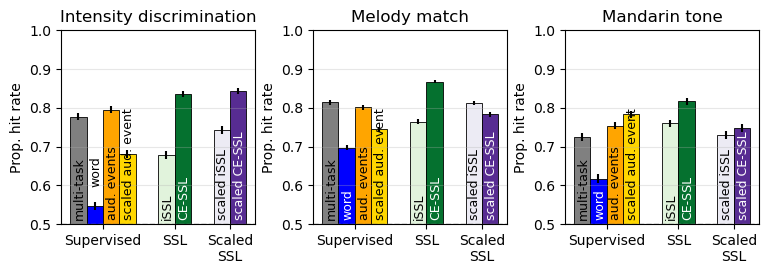

In [8]:
from matplotlib.container import BarContainer

# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


# -- Name models for plot -- 
main_plot_models  = [
        'CochCNN9 supervised multi-task',
        'CochCNN9 supervised word',
        'CochCNN9 supervised audioset',
        'CochCNN9 scaled supervised',
        'CochCNN9 ssl λ=0.0',
        'CochCNN9 ssl λ=0.5',
        'CochCNN9 scaled ssl λ=0.0',
        'CochCNN9 scaled ssl λ=0.5',
]

main_plot_df = no_byola_df[no_byola_df.model_name.isin(main_plot_models)]
hue_order = _models_in_data(main_plot_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

legend_labels = [model_label(m) for m in hue_order]


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = ['relu4']
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            main_plot_df[(main_plot_df["layer"] == layer) & (main_plot_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_grouped_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="Prop. hit rate", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0, group_gap=0.25,
            )
        task_name_to_plot = task_name.replace(" discrimination", "")
        if task_name_to_plot == "Loudness order":
            task_name_to_plot = "Intensity discrimination"
        ax.set_title(task_name_to_plot)
        ax.set_ylim(0.5, 1.0)
        ax.set_xlabel("")
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")
        # Access containers and filter if necessary (especially for multiple plot types)
        
        bars = []
        for container in ax.containers:
            if isinstance(container, BarContainer):
                bars.append(container)

        for b_ix, bar in enumerate(bars):
            bar_label = model_label(hue_order[b_ix], use_ssl_names=True)
            white_text_substrs=["word", "CE", "byol"]
            if 'Loudness' in task_name:
                white_text_substrs=[ "CE", "byol"]

            bar_label = bar_label.replace('supervised ', '')
            set_bar_labels(ax,
                       bar,
                       [bar_label],
                       white_text_substrs=white_text_substrs,
                       y_cut_for_olap=.6,
                       ymin_bars = 0.51,
                       no_olap_pad=0.05,
                       fontsize=9,
                       x_shift_size=0.0125,
                       )    

# Single legend below all panels
# plt.tight_layout()

# make all panels square 
ratio = 1.0
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

# adjust w and h space
fig.subplots_adjust(wspace=0.3)


# plt.savefig(fig_out_dir / "zero_shot_core_models_w_scaled_models.pdf", bbox_inches='tight',)# transparent=True)


In [10]:
no_byola_df

,pos_l2,neg_l2,pos_l2_sq,neg_l2_sq,l2_judgement,sqr_l2_judgement,judgement_pos_lt_neg,pos_cos,neg_cos,cos_judgement,...,interval,instrument,negative_interval,interval_diff,example_idx,speaker,tone,syllable_a,syllable_b,neg_tone
0,66.532600,71.647263,4426.586916,5133.330234,1,1,1,0.477745,0.273245,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,49.318130,57.860512,2432.277995,3347.838823,1,1,1,0.588890,0.313767,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,36.225403,40.322495,1312.279810,1625.903563,1,1,1,0.550662,0.334780,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31.986141,40.858196,1023.113229,1669.392202,1,1,1,0.674802,0.365338,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,35.052288,48.470074,1228.662898,2349.348044,1,1,1,0.754827,0.459288,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123180,787.675720,701.026794,620433.040216,491438.566514,0,0,0,0.223692,0.206464,1,...,NaN,NaN,NaN,NaN,1999.0,female_voice_3,3.0,min3,pang3,1.0
123181,230.612976,211.510391,53182.344734,44736.645601,0,0,0,0.603501,0.633056,0,...,NaN,NaN,NaN,NaN,1999.0,female_voice_3,3.0,min3,pang3,1.0
123182,412.609436,397.347443,170246.546705,157884.990162,0,0,0,0.371249,0.380572,0,...,NaN,NaN,NaN,NaN,1999.0,female_voice_3,3.0,min3,pang3,1.0
123183,37.217693,35.269375,1385.156697,1243.928802,0,0,0,0.548289,0.484245,1,...,NaN,NaN,NaN,NaN,1999.0,female_voice_3,3.0,min3,pang3,1.0


# main fig without groups



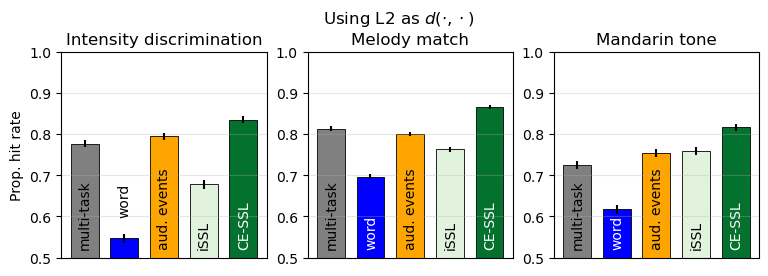

In [11]:
from matplotlib.container import BarContainer

# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


# -- Name models for plot -- 
main_plot_models  = [
        'CochCNN9 supervised multi-task',
        'CochCNN9 supervised word',
        'CochCNN9 supervised audioset',
        # 'CochCNN9 scaled supervised',
        'CochCNN9 ssl λ=0.0',
        'CochCNN9 ssl λ=0.5',
        # 'CochCNN9 scaled ssl λ=0.0',
        # 'CochCNN9 scaled ssl λ=0.5',
]

main_plot_df = no_byola_df[no_byola_df.model_name.isin(main_plot_models)]
hue_order = _models_in_data(main_plot_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

legend_labels = [model_label(m) for m in hue_order]


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = ['relu4']
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            main_plot_df[(main_plot_df["layer"] == layer) & (main_plot_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_sequential_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="Prop. hit rate", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0, 
            )
        task_name_to_plot = task_name.replace(" discrimination", "")
        if task_name_to_plot == "Loudness order":
            task_name_to_plot = "Intensity discrimination"
        ax.set_title(task_name_to_plot)
        ax.set_ylim(0.5, 1.0)
        if col_idx > 0:
            ax.set_ylabel("")
        ax.set_xlabel("")
        # ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        ax.set_xticks([])
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")
        # Access containers and filter if necessary (especially for multiple plot types)
        
        bars = []
        for container in ax.containers:
            if isinstance(container, BarContainer):
                bars.append(container)

        for b_ix, bar in enumerate(bars):
            bar_label = model_label(hue_order[b_ix], use_ssl_names=True)
            white_text_substrs=["word", "CE", "byol"]
            if 'Loudness' in task_name:
                white_text_substrs=[ "CE", "byol"]

            bar_label = bar_label.replace('supervised ', '')
            set_bar_labels(ax,
                       bar,
                       [bar_label],
                       white_text_substrs=white_text_substrs,
                       y_cut_for_olap=.6,
                       ymin_bars = 0.52,
                       no_olap_pad=0.05,
                       fontsize=10,
                       x_shift_size=0.0125,
                       )    

# Single legend below all panels

axes[0][0].set_ylabel("Prop. hit rate")#  ($l2_{ap} < l2_{an}$)")

# make all panels square 
ratio = 1.0
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

plt.suptitle('Using L2 as $d(\\cdot,\\cdot)$')
plt.savefig(fig_out_dir / "zero_shot_core_models_l2.pdf", bbox_inches='tight',)# transparent=True)
# 
# adjust w and h space
# fig.subplots_adjust(wspace=0.3)
 


In [12]:
plot_df.columns

Index(['pos_l2', 'neg_l2', 'pos_l2_sq', 'neg_l2_sq', 'l2_judgement',
       'sqr_l2_judgement', 'judgement_pos_lt_neg', 'pos_cos', 'neg_cos',
       'cos_judgement', 'pos_r', 'neg_r', 'r_judgement', 'model', 'batch_idx',
       'word1', 'word2', 'word1_higher', 'model_name', 'layer', 'task',
       'model_internal', 'interval', 'instrument', 'negative_interval',
       'interval_diff', 'example_idx', 'speaker', 'tone', 'syllable_a',
       'syllable_b', 'neg_tone'],
      dtype='object')

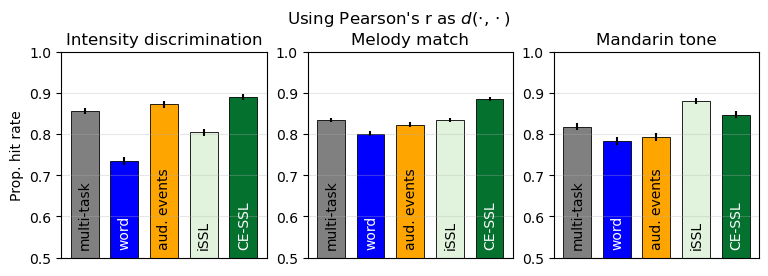

In [12]:
from matplotlib.container import BarContainer

# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "r_judgement"),
    ("Melody match", "r_judgement"),
    ("Mandarin tone discrimination", "r_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


# -- Name models for plot -- 
main_plot_models  = [
        'CochCNN9 supervised multi-task',
        'CochCNN9 supervised word',
        'CochCNN9 supervised audioset',
        # 'CochCNN9 scaled supervised',
        'CochCNN9 ssl λ=0.0',
        'CochCNN9 ssl λ=0.5',
        # 'CochCNN9 scaled ssl λ=0.0',
        # 'CochCNN9 scaled ssl λ=0.5',
]

main_plot_df = no_byola_df[no_byola_df.model_name.isin(main_plot_models)]
hue_order = _models_in_data(main_plot_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

legend_labels = [model_label(m) for m in hue_order]


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = ['relu4']
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            main_plot_df[(main_plot_df["layer"] == layer) & (main_plot_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_sequential_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0, 
            )
        task_name_to_plot = task_name.replace(" discrimination", "")
        if task_name_to_plot == "Loudness order":
            task_name_to_plot = "Intensity discrimination"
        ax.set_title(task_name_to_plot)
        ax.set_ylim(0.5, 1.0)
        # if col_idx > 0:
        ax.set_ylabel("")
        ax.set_xlabel("")
        # ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        ax.set_xticks([])
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")
        # Access containers and filter if necessary (especially for multiple plot types)
        
        bars = []
        for container in ax.containers:
            if isinstance(container, BarContainer):
                bars.append(container)

        for b_ix, bar in enumerate(bars):
            bar_label = model_label(hue_order[b_ix], use_ssl_names=True)
            white_text_substrs=["word", "CE", "byol"]
            # if 'Loudness' in task_name:
            #     white_text_substrs=[ "CE", "byol"]

            bar_label = bar_label.replace('supervised ', '')
            set_bar_labels(ax,
                       bar,
                       [bar_label],
                       white_text_substrs=white_text_substrs,
                       y_cut_for_olap=.6,
                       ymin_bars = 0.52,
                       no_olap_pad=0.05,
                       fontsize=10,
                       x_shift_size=0.0125,
                       )    

axes[0][0].set_ylabel("Prop. hit rate")#  ($r_{ap} > r_{an}$)")

# Single legend below all panels
# plt.tight_layout()

# make all panels square 
ratio = 1.0
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
plt.suptitle("Using Pearson's r as $d(\\cdot,\\cdot)$")

plt.savefig(fig_out_dir / "zero_shot_core_models_corr_based.pdf", bbox_inches='tight',)# transparent=True)

# adjust w and h space
# fig.subplots_adjust(wspace=0.3)
 


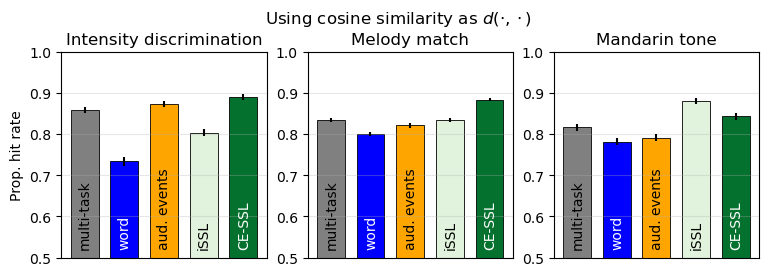

In [13]:
from matplotlib.container import BarContainer

# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "cos_judgement"),
    ("Melody match", "cos_judgement"),
    ("Mandarin tone discrimination", "cos_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


# -- Name models for plot -- 
main_plot_models  = [
        'CochCNN9 supervised multi-task',
        'CochCNN9 supervised word',
        'CochCNN9 supervised audioset',
        # 'CochCNN9 scaled supervised',
        'CochCNN9 ssl λ=0.0',
        'CochCNN9 ssl λ=0.5',
        # 'CochCNN9 scaled ssl λ=0.0',
        # 'CochCNN9 scaled ssl λ=0.5',
]

main_plot_df = no_byola_df[no_byola_df.model_name.isin(main_plot_models)]
hue_order = _models_in_data(main_plot_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

legend_labels = [model_label(m) for m in hue_order]


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = ['relu4']
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            main_plot_df[(main_plot_df["layer"] == layer) & (main_plot_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_sequential_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0, 
            )
        task_name_to_plot = task_name.replace(" discrimination", "")
        if task_name_to_plot == "Loudness order":
            task_name_to_plot = "Intensity discrimination"
        ax.set_title(task_name_to_plot)
        ax.set_ylim(0.5, 1.0)
        # if col_idx > 0:
        ax.set_ylabel("")
        ax.set_xlabel("")
        # ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        ax.set_xticks([])
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")
        # Access containers and filter if necessary (especially for multiple plot types)
        
        bars = []
        for container in ax.containers:
            if isinstance(container, BarContainer):
                bars.append(container)

        for b_ix, bar in enumerate(bars):
            bar_label = model_label(hue_order[b_ix], use_ssl_names=True)
            white_text_substrs=["word", "CE", "byol"]
            # if 'Loudness' in task_name:
            #     white_text_substrs=[ "CE", "byol"]

            bar_label = bar_label.replace('supervised ', '')
            set_bar_labels(ax,
                       bar,
                       [bar_label],
                       white_text_substrs=white_text_substrs,
                       y_cut_for_olap=.6,
                       ymin_bars = 0.52,
                       no_olap_pad=0.05,
                       fontsize=10,
                       x_shift_size=0.0125,
                       )    

axes[0][0].set_ylabel("Prop. hit rate") #  ($cos_{ap} > cos_{an}$)")

# Single legend below all panels
# plt.tight_layout()

# make all panels square 
ratio = 1.0
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
plt.suptitle("Using cosine similarity as $d(\\cdot,\\cdot)$")

plt.savefig(fig_out_dir / "zero_shot_core_models_cos_based.pdf", bbox_inches='tight',)# transparent=True)

# adjust w and h space
# fig.subplots_adjust(wspace=0.3)
 


# Main fig with gruoped bars

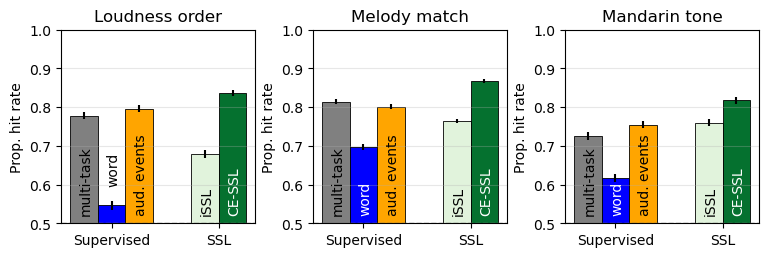

In [14]:
from matplotlib.container import BarContainer

# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


# -- Name models for plot -- 
main_plot_models  = [
        'CochCNN9 supervised multi-task',
        'CochCNN9 supervised word',
        'CochCNN9 supervised audioset',
        # 'CochCNN9 scaled supervised',
        'CochCNN9 ssl λ=0.0',
        'CochCNN9 ssl λ=0.5',
        # 'CochCNN9 scaled ssl λ=0.0',
        # 'CochCNN9 scaled ssl λ=0.5',
]

main_plot_df = no_byola_df[no_byola_df.model_name.isin(main_plot_models)]
hue_order = _models_in_data(main_plot_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

legend_labels = [model_label(m) for m in hue_order]


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = ['relu4']
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            main_plot_df[(main_plot_df["layer"] == layer) & (main_plot_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_grouped_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="Prop. hit rate", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0, group_gap=0.25,
            )
        ax.set_title(task_name.replace(" discrimination", ""))
        ax.set_ylim(0.5, 1.0)
        ax.set_xlabel("")
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")
        # Access containers and filter if necessary (especially for multiple plot types)
        
        bars = []
        for container in ax.containers:
            if isinstance(container, BarContainer):
                bars.append(container)

        for b_ix, bar in enumerate(bars):
            bar_label = model_label(hue_order[b_ix], use_ssl_names=True)
            white_text_substrs=["word", "CE", "byol"]
            if 'Loudness' in task_name:
                white_text_substrs=[ "CE", "byol"]

            bar_label = bar_label.replace('supervised ', '')
            set_bar_labels(ax,
                       bar,
                       [bar_label],
                       white_text_substrs=white_text_substrs,
                       y_cut_for_olap=.6,
                       ymin_bars = 0.52,
                       no_olap_pad=0.05,
                       fontsize=10,
                       x_shift_size=0.0125,
                       )    

# Single legend below all panels
# plt.tight_layout()

# make all panels square 
ratio = 1.0
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

# adjust w and h space
fig.subplots_adjust(wspace=0.3)
 
# plt.savefig(fig_out_dir / "zero_shot_core_models.pdf", bbox_inches='tight',)# transparent=True)


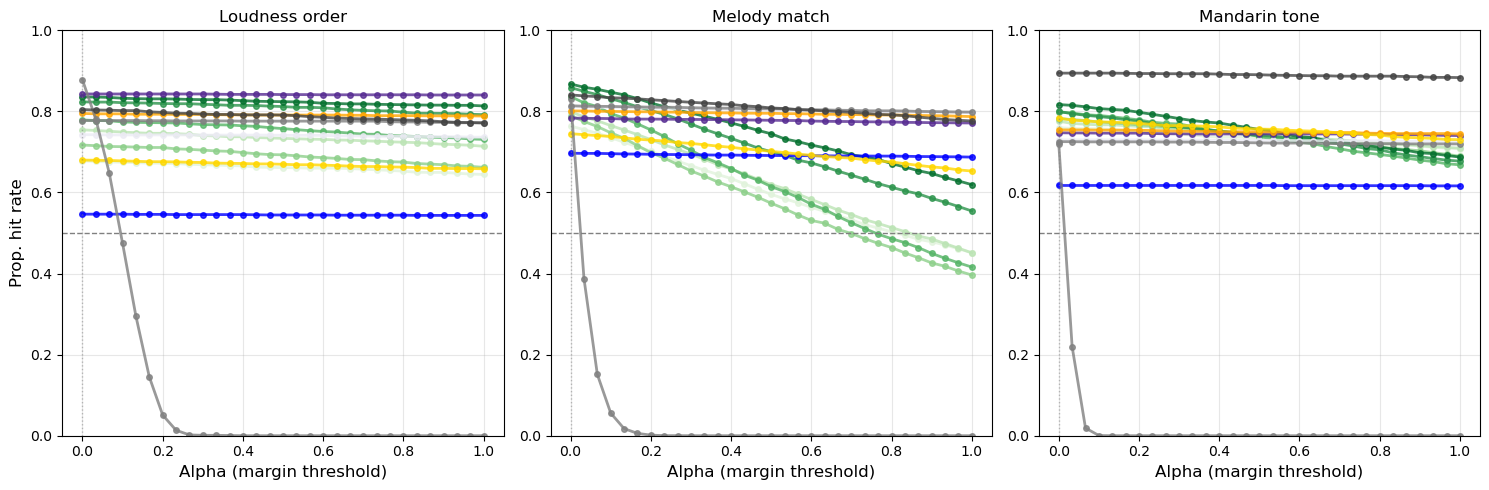

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]

def compute_hit_rate_with_alpha(df, alpha, pos_col='pos_l2', neg_col='neg_l2'):
    """
    Compute hit rate using judgment: pos_l2 + alpha < neg_l2
    """
    if df.empty or pos_col not in df.columns or neg_col not in df.columns:
        return np.nan
    judgement = (df[pos_col] + alpha < df[neg_col]).astype(float)
    return judgement.mean()

def create_alpha_line_plots(main_plot_df, hue_order, hue_dict, 
                           alpha_range=None, task_config=TASK_CONFIG,
                           random_state=42):
    """
    Create line plots with alpha on x-axis and each model as a colored line.
    Uses half the trials per model.
    """
    if alpha_range is None:
        alpha_range = np.linspace(0, 1, 31)
    
    np.random.seed(random_state)
    
    layers = ['relu4']
    n_cols = len(task_config)
    base_size = 5
    
    fig, axes = plt.subplots(1, n_cols, figsize=(base_size * n_cols, base_size))
    
    if n_cols == 1:
        axes = [axes]
    
    for col_idx, (task_name, value_col) in enumerate(task_config):
        ax = axes[col_idx]
        layer = layers[0]
        
        # For each model, compute hit rates across alpha range
        for model_name in hue_order:
            model_df = main_plot_df[
                (main_plot_df["model_name"] == model_name) & 
                (main_plot_df["task"] == task_name) & 
                (main_plot_df["layer"] == layer)
            ].copy()
            
            if not model_df.empty:
                # Use only half the trials
                n_trials = len(model_df)
                indices = np.random.permutation(n_trials)
                half_point = n_trials // 2
                half_trials_idx = indices[:half_point]
                model_df_half = model_df.iloc[half_trials_idx]
                
                hit_rates = []
                for alpha in alpha_range:
                    hit_rate = compute_hit_rate_with_alpha(model_df, alpha)
                    hit_rates.append(hit_rate)
                
                # Plot line for this model
                color = hue_dict[model_name]
                label = model_label(model_name, use_ssl_names=True)
                label = label.replace('supervised ', '')
                
                ax.plot(alpha_range, hit_rates, '-o', color=color, 
                       label=label, linewidth=2, markersize=4, alpha=0.8)
        
        # Formatting
        ax.set_ylim(0, 1.0)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.axvline(0.0, color="gray", linestyle=":", linewidth=1, alpha=0.5)
        ax.grid(axis="both", alpha=0.3, zorder=-1)
        
        ax.set_xlabel("Alpha (margin threshold)", fontsize=12)
        if col_idx == 0:
            ax.set_ylabel("Prop. hit rate", fontsize=12)
        
        ax.set_title(task_name.replace(" discrimination", ""), fontsize=12)
        # ax.legend(fontsize=9, loc='best', ncol=4)
    
    fig.tight_layout()
    
    return fig, axes

# ============================================================================
# USAGE
# ============================================================================

# Define alpha range to sweep
alpha_range = np.linspace(0, 1, 31)  # 31 points from -0.3 to 0.3
hue_order = ['CochCNN9 ssl λ=0.0', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2',
       'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5',
       'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5',
       'CochCNN9 supervised word', 'CochCNN9 supervised audioset',
       'CochCNN9 supervised multi-task', 'CochCNN9 scaled supervised',
       'CochCNN9 random weights', 'byol-a']

base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)
hue_dict['CochCNN9 random weights'] = "grey"

# Create the plot
fig, axes = create_alpha_line_plots(
    results_df, hue_order, hue_dict,
    alpha_range=alpha_range,
    task_config=TASK_CONFIG,
    random_state=42
)

# plt.savefig("alpha_line_plots_half_trials.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [38]:
hue_dict.keys()

dict_keys(['CochCNN9 ssl λ=0.0', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5', 'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5', 'CochCNN9 supervised word', 'CochCNN9 supervised audioset', 'CochCNN9 supervised multi-task', 'CochCNN9 scaled supervised', 'CochCNN9 random weights', 'byol-a'])

## Plot three panels (CochCNN9 / BYOL-A)

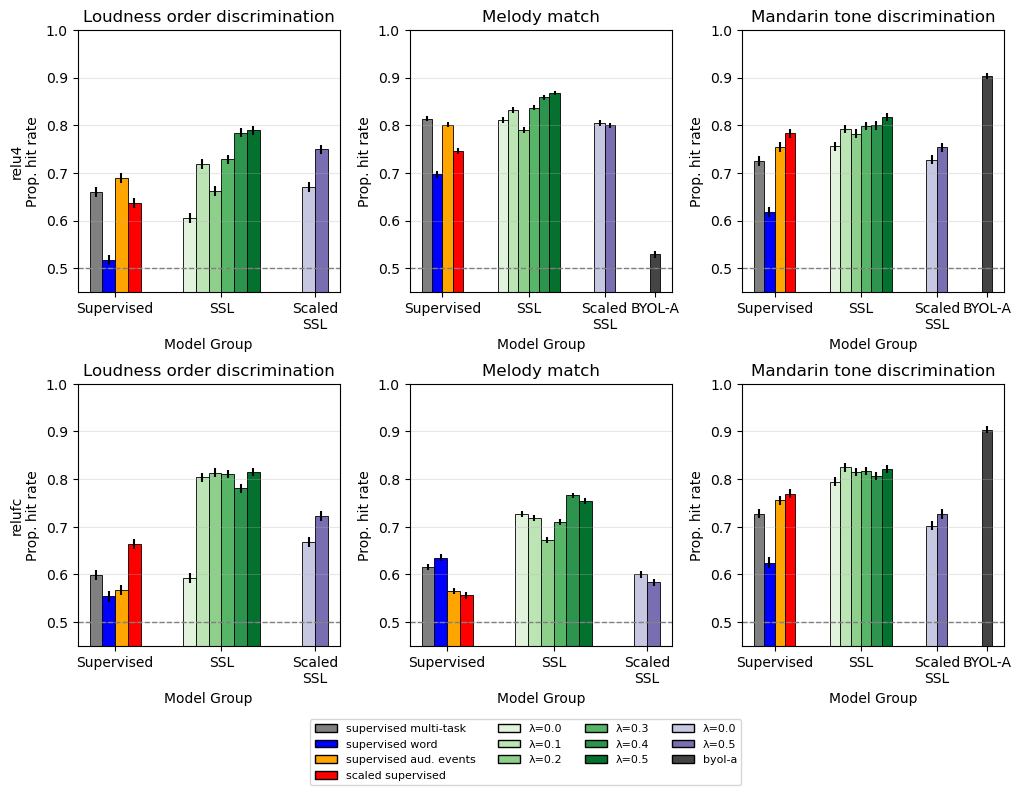

In [4]:
# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


hue_order = _models_in_data(results_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = sorted(results_df["layer"].dropna().unique())
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            results_df[(results_df["layer"] == layer) & (results_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_grouped_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="Prop. hit rate", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0,
            )
        ax.set_title(task_name)
        ax.set_ylim(0.45, 1.0)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")

# Single legend below all panels
legend_handles = [Patch(facecolor=hue_dict.get(m, "#444444"), edgecolor="black") for m in hue_order]
legend_labels = [model_label(m) for m in hue_order]
fig.legend(
    legend_handles, legend_labels,
    frameon=True, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, .025), ncol=4,
)
# plt.tight_layout()

# make all panels square 
ratio = 1.0 
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

# adjust w and h space
fig.subplots_adjust(wspace=0.25, hspace=0.35)
 


## Without BYOL-A

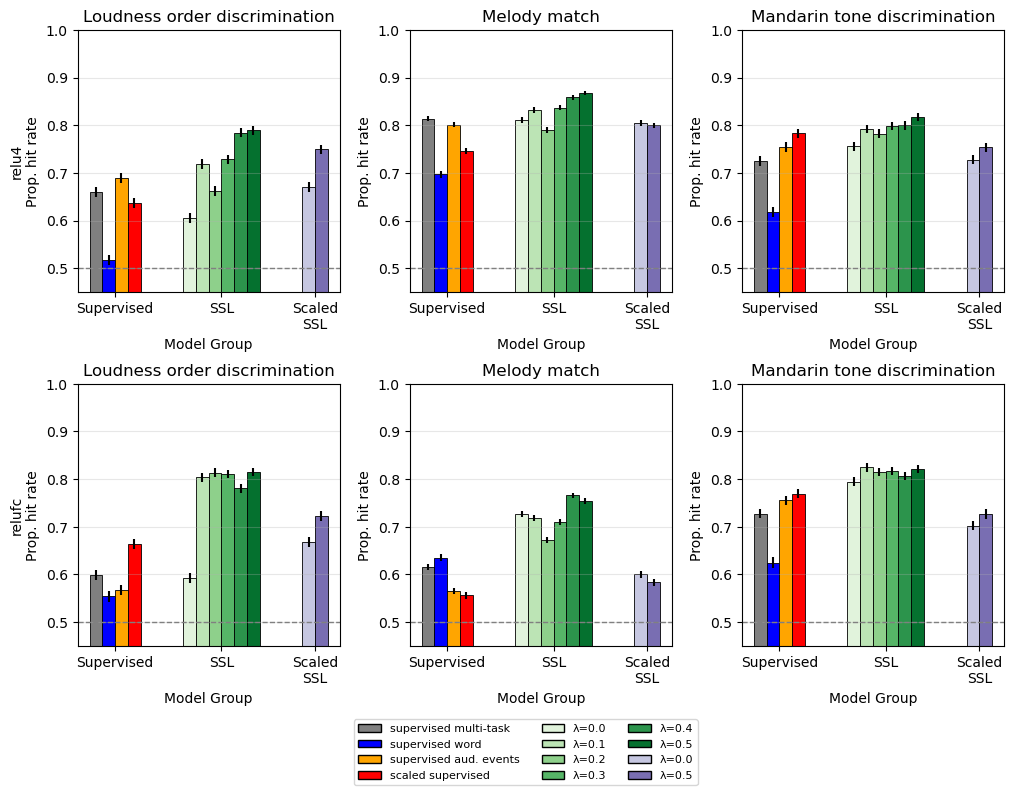

In [10]:
# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


hue_order = _models_in_data(no_byola_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = sorted(no_byola_df["layer"].dropna().unique())
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            no_byola_df[(no_byola_df["layer"] == layer) & (no_byola_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_grouped_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="Prop. hit rate", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0,
            )
        ax.set_title(task_name)
        ax.set_ylim(0.45, 1.0)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")

# Single legend below all panels
legend_handles = [Patch(facecolor=hue_dict.get(m, "#444444"), edgecolor="black") for m in hue_order]
legend_labels = [model_label(m) for m in hue_order]
fig.legend(
    legend_handles, legend_labels,
    frameon=True, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, .025), ncol=3,
)
# plt.tight_layout()

# make all panels square 
ratio = 1.0 
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

# adjust w and h space
fig.subplots_adjust(wspace=0.25, hspace=0.35)
 
